
# Computer Exercise 10.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 10.3 Simulation — *Buffon's Needle Problem*
> **풀이 일자**: Day 39
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)



## 1. 문제 (원문)

> **1.** Simulate **Buffon's needle experiment**. A needle of length $\ell$ is dropped
> at random onto a plane ruled with parallel lines a distance $t \ge \ell$ apart.
> Using a random-number generator, drop $N$ needles, count the number $H$ that cross
> a line, and estimate $\pi$ from the relation $P = \dfrac{2\ell}{\pi t}$, i.e.
> $\hat\pi = \dfrac{2\ell N}{t\,H}$. Tabulate the estimate and its error as $N$
> grows, and verify empirically that the error decreases like $\mathcal{O}(N^{-1/2})$.

### 한국어 풀이용 정리
평행선 간격 $t$, 바늘 길이 $\ell\,(\le t)$. 바늘을 무작위로 떨어뜨릴 때 선과 **교차할 확률**이
$P = 2\ell/(\pi t)$ 라는 사실을 거꾸로 이용해 $\pi$ 를 추정한다. 핵심은 (1) 시뮬레이션의
무작위 입력을 어떻게 잡느냐, (2) 추정량의 오차가 표본수 $N$ 에 대해 $N^{-1/2}$ 로 줄어드는지 확인.



## 2. 수학적 배경

### 2.1 교차 확률
바늘 중심에서 가장 가까운 선까지의 거리 $y\sim\mathrm{Unif}[0,\,t/2]$, 바늘과 선의 예각
$\theta\sim\mathrm{Unif}[0,\,\pi/2]$ 가 독립이라 하자. 바늘이 선을 **교차**하는 조건은
$$
y \le \frac{\ell}{2}\sin\theta .
$$
따라서 교차 확률은
$$
P=\frac{\int_0^{\pi/2}\frac{\ell}{2}\sin\theta\,d\theta}{(t/2)(\pi/2)}
 =\frac{\ell}{(t/2)(\pi/2)}=\boxed{\dfrac{2\ell}{\pi t}} .
$$

### 2.2 $\pi$ 추정량과 오차
$N$ 번 중 $H$ 번 교차하면 $\hat P=H/N$, 이를 뒤집어
$$
\boxed{\;\hat\pi=\frac{2\ell}{t\,\hat P}=\frac{2\ell N}{t\,H}\;}.
$$
$H\sim\mathrm{Binomial}(N,P)$ 이므로 $\mathrm{Var}[\hat P]=P(1-P)/N$, 즉
$\hat P$ 의 표준오차는 $\mathcal{O}(N^{-1/2})$. 델타법으로 $\hat\pi$ 도
$$
\mathrm{SE}[\hat\pi]\approx\frac{2\ell}{t}\frac{\sqrt{P(1-P)}}{P^2}\,N^{-1/2}
=\mathcal{O}(N^{-1/2}).
$$
**느리다**: 자릿수 하나 더 얻으려면 표본을 100배 늘려야 한다.



## 3. 풀이 흐름

1. **무작위 입력 생성**: 중심-선 거리 $y\sim U[0,t/2]$, 각도 $\theta\sim U[0,\pi/2]$.
2. **교차 판정**: $y \le (\ell/2)\sin\theta$ 인 바늘을 집계해 $H$ 계산.
3. **추정량**: $\hat\pi = 2\ell N/(tH)$ (단, $H>0$).
4. **수렴 표**: $N=10^2,10^3,\dots,10^6$ 에서 $\hat\pi$ 와 절대오차 정리.
5. **누적 추정 곡선**: $N$ 이 늘면서 $\hat\pi$ 가 $\pi$ 로 수렴하는 모습 시각화.
6. **오차 스케일링**: 여러 $N$ 에서 반복 실험해 RMS 오차 vs $N$ 을 log-log, 기울기 $-1/2$ 기준선과 비교.
7. **해석**: 왜 이렇게 느린가, 분산 감소가 필요한 이유로 연결.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.6g}")
rng = np.random.default_rng(39)

t, ell = 1.0, 1.0          # 선 간격 t, 바늘 길이 ell (ell <= t)

def buffon(N, rng):
    """N개의 바늘을 떨어뜨려 교차 횟수 H 반환."""
    y = rng.uniform(0.0, t / 2.0, size=N)          # 중심-선 거리
    th = rng.uniform(0.0, np.pi / 2.0, size=N)     # 예각
    H = np.count_nonzero(y <= (ell / 2.0) * np.sin(th))
    return H

def pi_hat(N, rng):
    H = buffon(N, rng)
    return np.inf if H == 0 else (2.0 * ell * N) / (t * H)

print("이론 교차확률 P = 2l/(pi t) =", 2 * ell / (np.pi * t))


이론 교차확률 P = 2l/(pi t) = 0.6366197723675814


In [2]:
# --- 수렴 표: N을 키우며 단일 실행 추정값 ---
rows = []
for N in [10**2, 10**3, 10**4, 10**5, 10**6]:
    est = pi_hat(N, rng)
    rows.append({"N": N, "pi_hat": est, "abs_err": abs(est - np.pi),
                 "rel_err": abs(est - np.pi) / np.pi})
df = pd.DataFrame(rows)
df


,N,pi_hat,abs_err,rel_err
0,100,3.84615,0.704561,0.224269
1,1000,3.2,0.0584073,0.0185916
2,10000,3.12793,0.0136602,0.00434818
3,100000,3.16186,0.0202627,0.00644983
4,1000000,3.13975,0.00184565,0.00058749


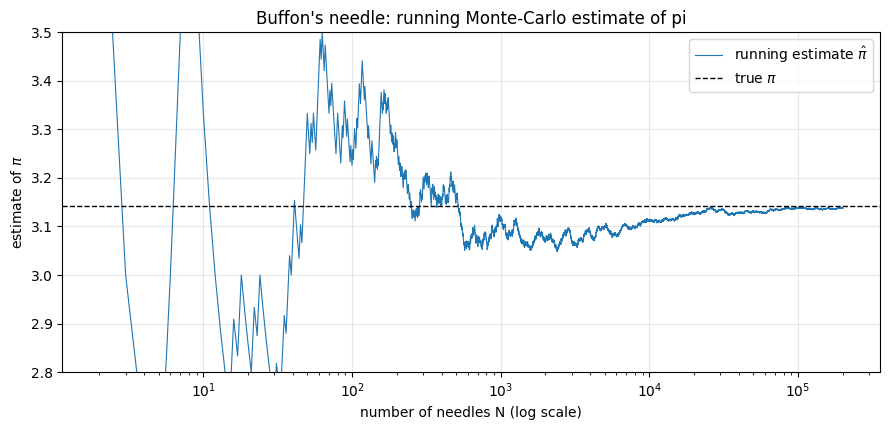

In [3]:
# --- 누적 추정 곡선: 바늘을 하나씩 추가하며 pi_hat 추적 ---
M = 200_000
y = rng.uniform(0.0, t / 2.0, size=M)
th = rng.uniform(0.0, np.pi / 2.0, size=M)
hit = (y <= (ell / 2.0) * np.sin(th)).astype(float)
n = np.arange(1, M + 1)
cum_hits = np.cumsum(hit)
with np.errstate(divide="ignore"):
    running = (2.0 * ell * n) / (t * cum_hits)

plt.figure(figsize=(9, 4.4))
plt.plot(n, running, lw=0.8, label=r"running estimate $\hat\pi$")
plt.axhline(np.pi, color="k", ls="--", lw=1, label=r"true $\pi$")
plt.xscale("log")
plt.ylim(2.8, 3.5)
plt.xlabel("number of needles N (log scale)")
plt.ylabel(r"estimate of $\pi$")
plt.title("Buffon's needle: running Monte-Carlo estimate of pi")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


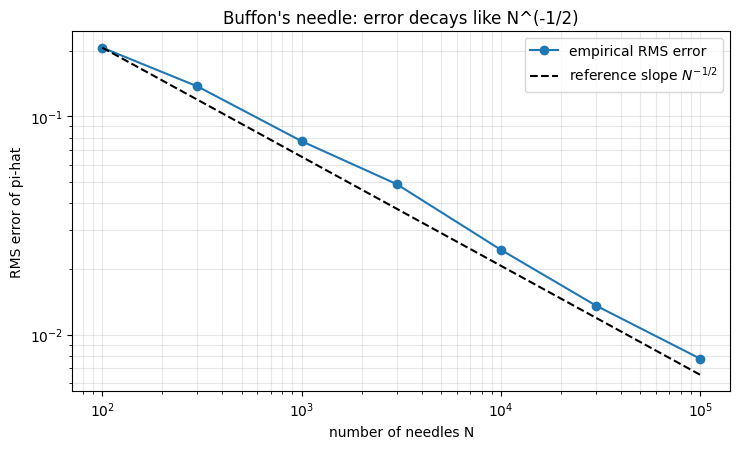

측정된 log-log 기울기 = -0.485  (이론 -0.5)


In [4]:
# --- 오차 스케일링: 각 N에서 R회 반복, RMS 오차 vs N ---
Ns = np.array([100, 300, 1000, 3000, 10000, 30000, 100000])
R = 60
rms = []
for N in Ns:
    errs = [pi_hat(int(N), rng) - np.pi for _ in range(R)]
    errs = [e for e in errs if np.isfinite(e)]
    rms.append(np.sqrt(np.mean(np.square(errs))))
rms = np.array(rms)

ref = rms[0] * np.sqrt(Ns[0]) / np.sqrt(Ns)     # N^{-1/2} 기준선
plt.figure(figsize=(7.5, 4.6))
plt.loglog(Ns, rms, "o-", label="empirical RMS error")
plt.loglog(Ns, ref, "k--", label=r"reference slope $N^{-1/2}$")
plt.xlabel("number of needles N"); plt.ylabel("RMS error of pi-hat")
plt.title("Buffon's needle: error decays like N^(-1/2)")
plt.grid(True, which="both", alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

slope = np.polyfit(np.log(Ns), np.log(rms), 1)[0]
print(f"측정된 log-log 기울기 = {slope:.3f}  (이론 -0.5)")



## 4. 결과 해석

1. **수렴 표**: $N$ 이 $10^2\to10^6$ 으로 100만 배 늘어도 절대오차는 대략 $10^{-1}\to10^{-3}$
   수준으로만 줄어든다 — 자릿수 3개 얻는 데 표본 100만 개.
2. **누적 곡선**: 초반에는 $\hat\pi$ 가 심하게 출렁이다가 $N$ 이 커지며 $\pi$ 선으로 수렴.
   로그 가로축에서 *진폭이 천천히* 줄어드는 게 $N^{-1/2}$ 의 시각적 증거다.
3. **오차 스케일링**: log-log 기울기가 $\approx-0.5$ 로 측정되어 이론 $\mathcal{O}(N^{-1/2})$ 와 일치.
4. **원인**: $H\sim\mathrm{Binomial}(N,P)$ 의 표준편차가 $\sqrt{NP(1-P)}$ 라, 비율 $\hat P=H/N$
   의 오차가 $N^{-1/2}$ 로만 줄어든다. 시뮬레이션 기반 추정의 *본질적* 한계.

> **결론**: Buffon 바늘은 시뮬레이션으로 $\pi$ 를 뽑아내는 고전 예제지만, 오차가
> $N^{-1/2}$ 로만 줄어 *정밀 계산용으로는 비효율적*이다 — 분산 감소 기법의 동기.

**다음 문제로의 연결**: 같은 $N^{-1/2}$ 거동이 **랜덤 워크**의 평균 이동거리 $\sim\sqrt{N}$
법칙에서도 나타난다. CE 10.3-2 에서 확인한다.
